## Versuch 5: Digitalisierung
In diesem Versuch wird die Umwandlung von analogen in digitale Daten untersucht.

Eine Funktion zum Auslesen einer Reihe von Werten aus der Karte und ihrer Darstellung. <br>
Eine Funktion, die eine Konsoleneingabe auf die Karte ausgibt und überprüft.

Den theoretischen Quantisierungsfehler des 11-Bit-AD-Wandlers berechnen:
$$
\Delta U = \frac{U_{max} - U_{min}}{2^n}
$$

In [1]:
u_max = 10.0  # maximale Eingangsspannung
u_min = -10.0  # minimale Eingangsspannung
n = 11  # Anzahl Bits

delta_u = (u_max - u_min) / (2 ** n)

print(f"Der theoretische Quantisierungsfehler für einen {n}-bit AD-Wandler mit einem Bereich von {u_min}V bis {u_max}V beträgt {delta_u:.5f}V")

Der theoretische Quantisierungsfehler für einen 11-bit AD-Wandler mit einem Bereich von -10.0V bis 10.0V beträgt 0.00977V


Messfehler ei = Ui,ref − Ui und Standardabweichung für das Multimeter und den AD-Wandler berechnen mit:
$$
S = \sqrt{\frac{1}{n-1} \sum_{i=1}^n e_i^2} = \sqrt{\frac{1}{n-1} \sum_{i=1}^n (U_{i,\text{ref}} - U_i)^2}
$$

In [2]:
import pandas as pd

# Daten laden
df = pd.read_csv('Aufgabe2.csv', delimiter=';')

# relevante Spalten in numerische Werte umwandeln
df['Keithley'] = pd.to_numeric(df['Keithley'].str.replace(',', '.'))
df['Multimeter'] = pd.to_numeric(df['Multimeter'].str.replace(',', '.'))
df['Python'] = pd.to_numeric(df['Python'].str.replace(',', '.'))

# Messfehler für Multimeter und Python (AD-Wandler) berechnen
df['Fehler_Multimeter'] = df['Keithley'] - df['Multimeter']
df['Fehler_Python'] = df['Keithley'] - df['Python']

print(f"Messfehler für jeden Tabelleneintrag:\n")
print(df[['OG Spannung', 'Fehler_Multimeter', 'Fehler_Python']])

# Standardabweichung für Multimeter und Python berechnen
std_multimeter = df['Fehler_Multimeter'].std(ddof=1)
std_Python = df['Fehler_Python'].std(ddof=1)

print(f"\nStandardabweichung des Multimeters: {std_multimeter:.5f} V")
print(f"Standardabweichung des Pythons: {std_Python:.5f} V")


Messfehler für jeden Tabelleneintrag:

   OG Spannung  Fehler_Multimeter  Fehler_Python
0            1              0.001         0.0110
1            2              0.001         0.0000
2            3             -0.001         0.0000
3            4              0.003         0.0105
4            5              0.000         0.0117
5            6             -0.003         0.0130
6            7             -0.001         0.0070
7            8             -0.005         0.0090
8            9             -0.007         0.0103
9           10              0.521         0.1101

Standardabweichung des Multimeters: 0.16520 V
Standardabweichung des Pythons: 0.03259 V


Den theoretischen Quantisierungsfehler des 10-Bit-DA-Wandlers (0V ...5V) berechnen:

In [3]:
u_max = 5.0  # maximale Ausgangsspannung
u_min = 0.0  # minimale Ausgangsspannung
n = 10  # Anzahl Bits

delta_u = (u_max - u_min) / (2 ** n)

print(f"Der theoretische Quantisierungsfehler für einen {n}-bit AD-Wandler mit einem Bereich von {u_min}V bis {u_max}V beträgt {delta_u:.5f}V")

Der theoretische Quantisierungsfehler für einen 10-bit AD-Wandler mit einem Bereich von 0.0V bis 5.0V beträgt 0.00488V


In [12]:
# Daten laden
df = pd.read_csv('Aufgabe3.csv', delimiter=';')

# relevante Spalten in numerische Werte umwandeln
df['Keithley'] = df['Keithley'].astype(str).str.replace(',', '.')
df['Python'] = df['Python'].astype(str).str.replace(',', '.')

df['Keithley'] = pd.to_numeric(df['Keithley'])
df['Python'] = pd.to_numeric(df['Python'])

# Messfehler für Python und Picoscope (AD-Wandler) berechnen
df['Fehler_Python'] = df['Keithley'] - df['Python']

print(f"Messfehler für jeden Tabelleneintrag:\n")
print(df[['Python', 'Fehler_Python']])

# Standardabweichung für Python und Picoscope berechnen
std_Python = df['Fehler_Python'].std(ddof=1)

print(f"\nStandardabweichung Python: {std_Python:.5f} V")


Messfehler für jeden Tabelleneintrag:

   Python  Fehler_Python
0     0.5          0.014
1     1.0          0.018
2     1.5          0.023
3     2.0          0.035
4     2.5          0.041
5     3.0          0.048
6     3.5          0.062
7     4.0          0.069
8     4.5          0.078
9     5.0          0.081

Standardabweichung Python: 0.02475 V


Tatsächliche Abtastfrequenz: 8000 <br>
Nuiquist-Frequenz: 4000

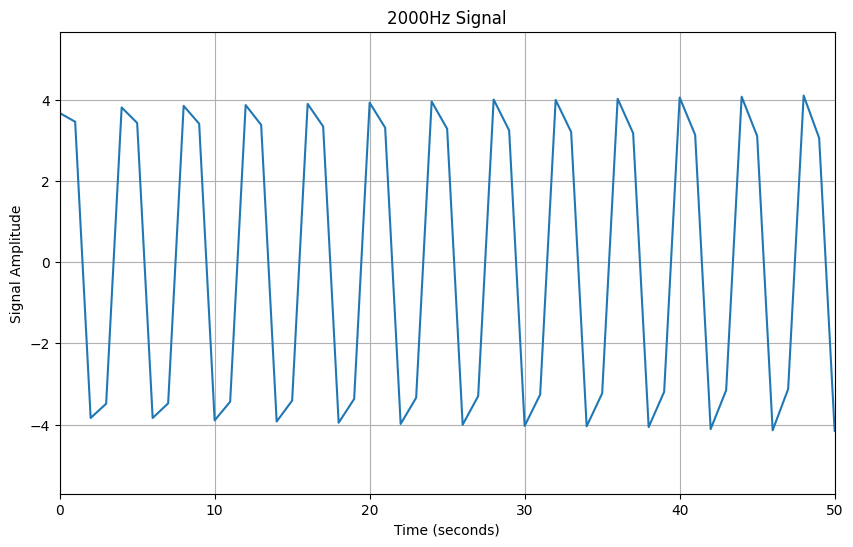

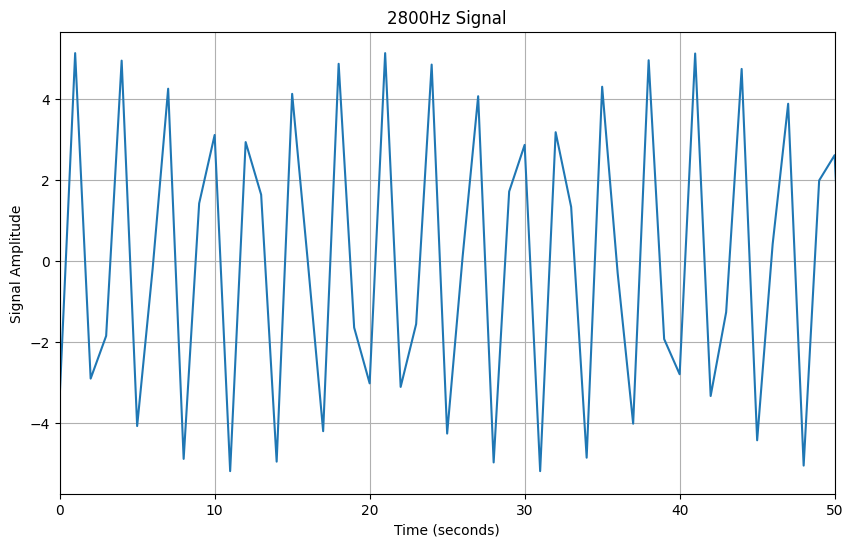

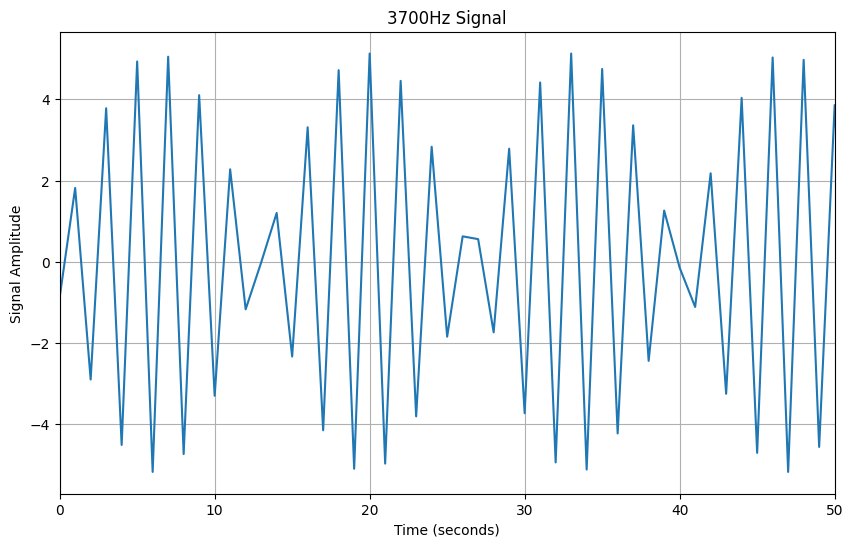

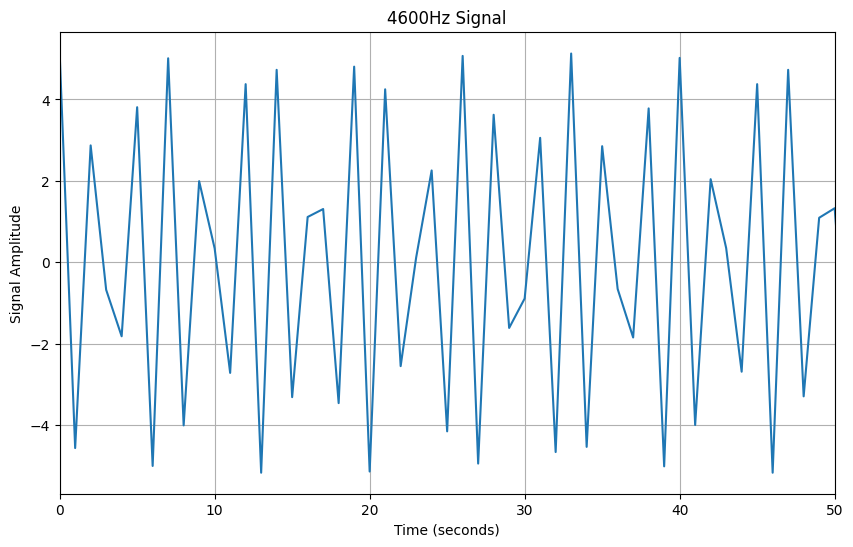

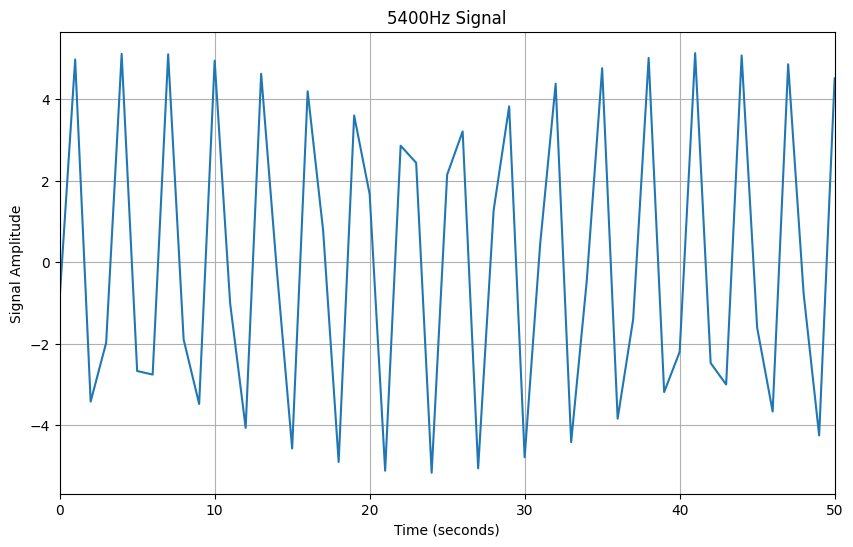

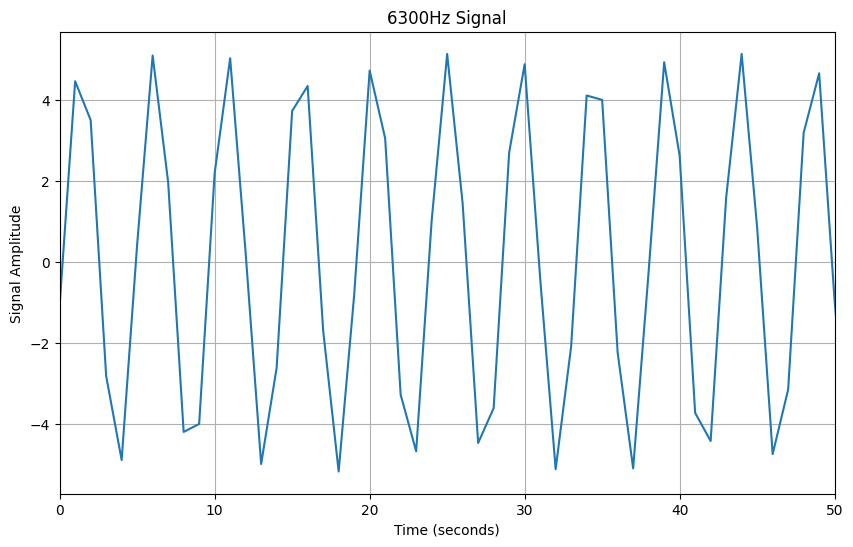

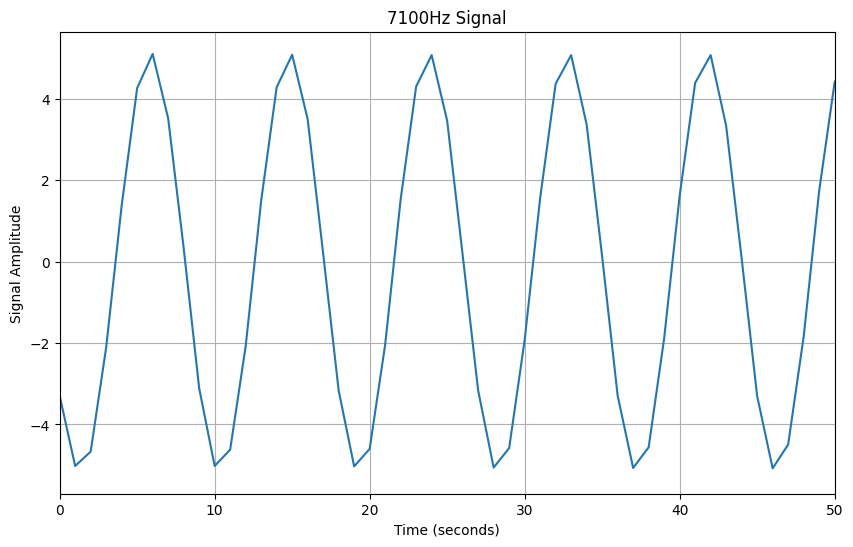

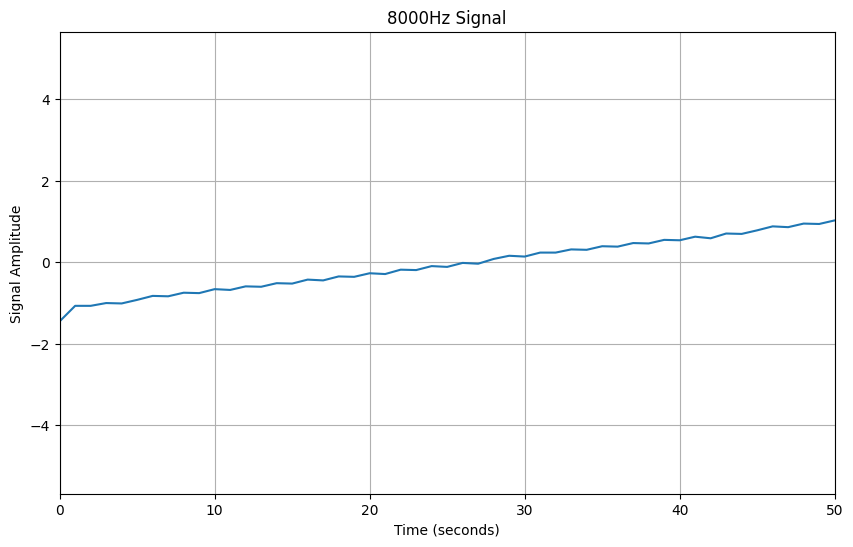

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def load(file_path):
    with open(file_path, 'r') as file:
        signal = np.fromstring(file.read(), sep=',')
        return signal

def plot(signal, title):
    plt.figure(figsize=(10, 6))
    plt.xlim(0,50)
    plt.plot(signal)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Signal Amplitude')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot(load(f'2000.txt'), f"2000Hz Signal")
plot(load(f'2800.txt'), f"2800Hz Signal")
plot(load(f'3700.txt'), f"3700Hz Signal")
plot(load(f'4600.txt'), f"4600Hz Signal")
plot(load(f'5400.txt'), f"5400Hz Signal")
plot(load(f'6300.txt'), f"6300Hz Signal")
plot(load(f'7100.txt'), f"7100Hz Signal")
plot(load(f'8000.txt'), f"8000Hz Signal")